In [ ]:
# compare with old method
import numpy as np
import pandas as pd
import pylab as plt
import seaborn as sn
import sys
sys.path.append('../')
import MHMDS.embed_funs as emb
import MHMDS.quality_metrics as qms
import pickle
from scipy import stats
import cmdstanpy as stan
import time
import os

# visulize 3-d embedding
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import plotly.colors

In [2]:
# plot parameters
plt.style.use('my_journal.mplstyle')
def clean_axis(ax=None):
    if ax is None:
        ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3)


In [3]:
# 
old_time = 828382
init = os.path.getmtime('../old-hMDS/benchmark/DistMat_Paul_PCA100/N2730_D3_embdat.p')-old_time

In [4]:
# read from file the comuting time
tps = []
times = np.linspace(200,2700,26)
for t in times:
    tps.append(os.path.getmtime('../old-hMDS/benchmark/DistMat_Paul_PCA100/N%i_D3_embdat.p'%t))
times = np.array(times)

In [5]:
newrunningtime = []
for t in times:
    newrunningtime.append(np.loadtxt('../MultiscalehMDS_distance/result/scaling/DistMat_Paul_PCA100_%i_time.txt'%t))
newrunningtime = np.array(newrunningtime)

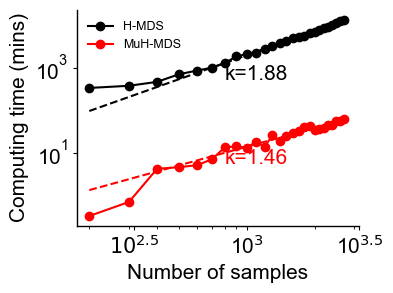

In [ ]:
# compute running time
runningtime = np.array([t-init for t in tps])
fig,axs = plt.subplots(figsize=(4,3))
axs.plot(times,runningtime/60.0,'k-o',label='H-MDS')
start = np.where(times==1000)[0][0]

res = np.polyfit(np.log2(times[start:]),np.log2(runningtime[start:]),1)
axs.plot(times,2**np.polyval(res,np.log2(times))/60.0,'k--')
axs.text(times[-20],runningtime[-20]/60.0*0.4,'k=%.2f'%(res[0]),fontsize=15)

axs.plot(times,newrunningtime/60.0,'r-o',label='MuH-MDS')
res = np.polyfit(np.log2(times[start:]),np.log2(newrunningtime[start:]),1)
axs.plot(times,2**np.polyval(res,np.log2(times))/60.0,'r--')
axs.text(times[-20],newrunningtime[-20]/60.0*0.4,'k=%.2f'%(res[0]),fontsize=15,color='r')

axs.set_ylabel('Computing time (mins)',fontsize=15)
axs.set_xlabel('Number of samples',fontsize=15)
axs.legend(fontsize=9,loc = 'upper left',frameon=False)
axs.set_yscale('log')
axs.set_xscale('log')
axs.tick_params(axis="x", labelsize=15)  
axs.tick_params(axis="y", labelsize=15)

axs.set_xticks([10**2.5,10**3,10**3.5])             
axs.set_xticklabels(['$10^{2.5}$','10$^{3}$','10$^{3.5}$'],fontsize=15)  


plt.tight_layout()
clean_axis(axs)
# plt.savefig('running_time.svg',format='svg',transparent=True)

In [7]:
# load data
fdname = '../old-hMDS/benchmark/DistMat_Paul_PCA100/N2730_D3_embdat.p'
with open(fdname, 'rb') as file:
    hyp_emb = pickle.load(file)


In [8]:
# distance matrix
dmat = emb.get_dmat_euc(np.loadtxt('../data/FeatMat_Paul_PCA100/FeatMat_Paul_PCA100.txt'))

In [9]:
dmat_nor = dmat/np.max(dmat)*2.0

In [10]:
emb.process_sim(hyp_emb)

In [11]:
# compute metric
N_sample = dmat.shape[0]
corr_old = stats.pearsonr(hyp_emb['emb_mat'][np.triu_indices(N_sample, k=1)],
                          dmat_nor[np.triu_indices(N_sample, k=1)])


In [12]:
Ql, Qg,_ = qms.get_quality_metrics(hyp_emb['emb_mat'],
                                           dmat_nor,verbose=False)

In [13]:
# computing time
old_time = 828382.326978

In [14]:
# new method
newmatname = 'cls_0.6_Nn_30_Nd_3_min_1_max_400'
metrics = pd.read_csv('../MultiscalehMDS_distance/result/DistMat_Paul_PCA100/%s_metrics.csv'%newmatname,index_col=0)


In [15]:
metrics

,Step,Qlocal,Qglobal,corr,runningtime,curvature,nunit,maxsizeofunit
0,1,0.465589,0.893854,0.944270,285.784129,8.09052,210.0,1.0
1,2,0.414741,0.826342,0.855718,610.641653,8.09052,210.0,377.0
2,MapOutlier,NaN,NaN,NaN,0.000000,8.09052,NaN,NaN
3,Avedmat,NaN,NaN,NaN,2.883555,NaN,NaN,NaN


In [ ]:
# compare quality
df_toplot = pd.DataFrame({'Method':['BHMDS','MuH-MDS'],
              'Qlocal':[Ql,metrics.Qlocal.iloc[1]],
             'Qglobal':[Qg,metrics.Qglobal.iloc[1]],
             'Correlation':[corr_old[0],metrics['corr'].iloc[1]],
             'Curvature':[hyp_emb['lambda'],metrics['curvature'].iloc[1]],
             'Computing Time':[old_time,metrics.runningtime.sum()]})

In [17]:
df_toplot

,Method,Qlocal,Qglobal,Correlation,Curvature,Computing Time
0,BHMDS,0.518583,0.879617,0.943675,7.947883763064498,828382.326978
1,MuH-MDS,0.414741,0.826342,0.855718,8.09052,899.309337


In [18]:
dfm = df_toplot.melt('Method', var_name='cols', value_name='vals')
dfm.vals = dfm.vals.astype(float)

<Axes: xlabel='cols', ylabel='vals'>

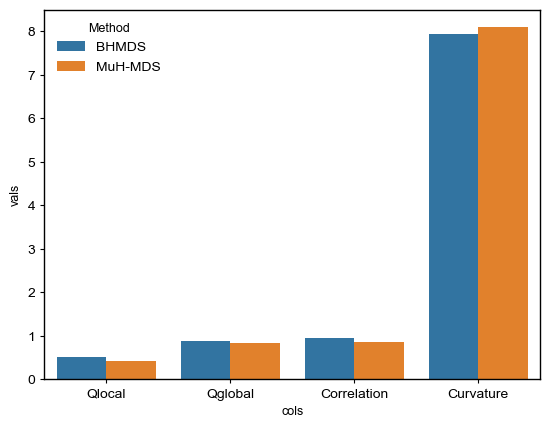

In [19]:
sn.barplot(data=dfm.iloc[:-2],x='cols',y='vals',hue='Method')

In [52]:
# visualization of the outcomes
metadata = pd.read_csv('../data/metadata/Paul_metadata.csv',index_col=0)
# hyp_emb['pcoords']

In [54]:
data_recenter = emb.perform_recenter(hyp_emb['pcoords'],np.arange(N_sample))

16:11:34 - cmdstanpy - INFO - Chain [1] start processing
16:11:35 - cmdstanpy - INFO - Chain [1] done processing


In [55]:
nativerc_old = emb.to_native(data_recenter)

In [ ]:
df_toplot_old = pd.concat([metadata,pd.DataFrame({'x':data_recenter[:,0],
                                             'y':data_recenter[:,1],
                                             'z':data_recenter[:,2]})],axis=1)

In [57]:
names = np.unique(df_toplot_old['paul15_clusters'])
ords = names[np.argsort([int(''.join(np.array(list(name))[np.char.isnumeric(list(name))])) for name in names])]

In [58]:
celltypes = [(''.join(np.array(list(name))[np.char.isalpha(list(name))])) 
             for name in df_toplot_old['paul15_clusters']]
df_toplot_old['celltype'] = celltypes

In [59]:
radii = np.linalg.norm(nativerc_old,axis=1)

In [60]:
fig = px.scatter_3d(df_toplot_old.iloc[np.where(radii<=8)[0]] , x='x', y='y', z='z',
                   color='celltype', opacity=1,size_max=10,size=np.ones((2724,)))
fig.show()

In [61]:
newemb = np.loadtxt('../MultiscalehMDS_distance/result/DistMat_Paul_PCA100/%s_coords_2730.txt'%newmatname)
inds = np.loadtxt('../MultiscalehMDS_distance/result/DistMat_Paul_PCA100/%s_inds_after_prep.txt'%newmatname)

In [62]:
newemb = newemb[np.argsort(inds)]

In [63]:
data_recenter_new = emb.perform_recenter(newemb,np.arange(N_sample))

16:11:51 - cmdstanpy - INFO - Chain [1] start processing
16:11:51 - cmdstanpy - INFO - Chain [1] done processing


In [64]:
nativerc_new = emb.to_native(data_recenter_new)

In [ ]:
df_toplot = pd.concat([metadata,pd.DataFrame({'x':data_recenter_new[:,0],
                                             'y':data_recenter_new[:,1],
                                             'z':data_recenter_new[:,2]})],axis=1)
df_toplot['celltype'] = celltypes

In [66]:
fig = px.scatter_3d(df_toplot , x='x', y='y', z='z',
                   color='celltype', opacity=1,size_max=10,size = np.ones((2730,)),
                   category_orders={'paul15_clusters':ords})
fig.show()

In [67]:
# 
embmat_new = emb.get_dmat_poin(newemb)/metrics['curvature'][0]

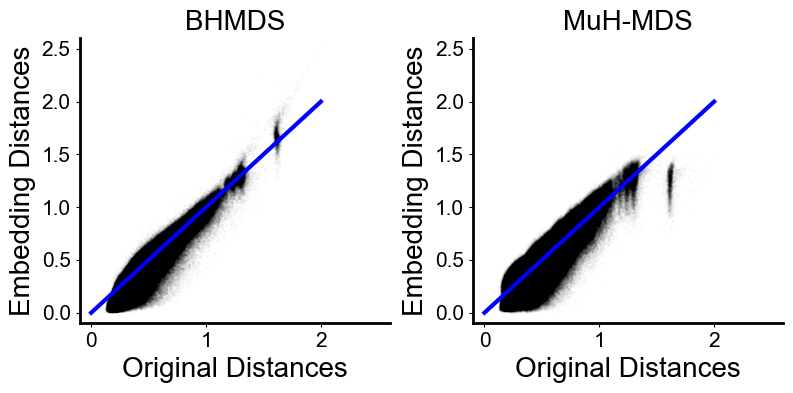

In [ ]:
# shepard diagram
fig,axs = plt.subplots(1,2,figsize=(8,4))
matlist = [hyp_emb['emb_mat'],embmat_new]
names = ['BHMDS','MuH-MDS']

# nooutlier = np.where(np.sum(dmat_nor,axis=0)<=4000)[0]
nooutlier = np.arange(len(dmat_nor))
N_sample = len(nooutlier)
for i in range(2):
    axs[i].scatter(dmat_nor[np.ix_(nooutlier,nooutlier)][np.triu_indices(N_sample, k=1)], 
                   matlist[i][np.ix_(nooutlier,nooutlier)][np.triu_indices(N_sample, k=1)],
                   s=1,alpha=0.01,
                 label=names[i],c='k')
    axs[i].set_title(names[i],fontsize=20)
    axs[i].plot(np.arange(0,3),np.arange(0,3),c='b',linewidth=3)
    width=2
    axs[i].spines['bottom'].set_linewidth(width)
    axs[i].spines['left'].set_linewidth(width)
    axs[i].spines[['right','top']].set_visible(False)
    axs[i].set_xlim([-0.1,2.6])
    axs[i].set_ylim([-0.1,2.6])

    axs[i].tick_params(axis="x", labelsize=15)  
    axs[i].tick_params(axis="y", labelsize=15)
    labels = [item.get_text() for item in axs[i].get_xticklabels()]
    axs[i].set_xlabel('Original Distances', fontsize=20)
    axs[i].set_ylabel('Embedding Distances', fontsize=20)
plt.tight_layout()
# plt.savefig('shepard_diagram.tiff',format='tiff',transparent=True, dpi = 300)